In [1]:
#import bert_score
#from deepeval.metrics import GEval
#from deepeval.test_case import LLMTestCase, LLMTestCaseParams
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
import pprint
from sklearn import metrics
import urllib

#from deepeval.models import AmazonBedrockModel

#import boto3
from pydantic_ai.models.bedrock import BedrockConverseModel
from pydantic_evals import Dataset, Case
from pydantic_evals.evaluators import LLMJudge
from pydantic_ai.settings import ModelSettings

import asyncio
import concurrent.futures

#from ragas.metrics import AnswerCorrectness 
#from ragas import EvaluationDataset, evaluate as ragas_evaluate
#from langchain_aws import ChatBedrockConverse, BedrockEmbeddings
#from ragas.llms import LangchainLLMWrapper
#from ragas.embeddings import LangchainEmbeddingsWrapper

import nest_asyncio
nest_asyncio.apply()

In [ ]:
normalise_threshold=True

In [3]:
settings={}
settings["n_prompts"] = 30
settings["region"] = "eu-west-2"
settings["temperature"] = 0
settings["threshold"] = 0.5

In [4]:
models = {}

#models['Claude 3 Haiku'] = 'anthropic.claude-3-haiku-20240307-v1:0'
models['Claude 3.7 Sonnet'] = 'anthropic.claude-3-7-sonnet-20250219-v1:0'
#models['GPT OSS 20b'] = "openai.gpt-oss-20b-1:0"
models['GPT OSS 120b'] = "openai.gpt-oss-120b-1:0"

## Set Environment Variables

In [5]:
os.environ["AWS_DEFAULT_REGION"] = settings["region"]

## Get Data

In [6]:
datasets = [
    'https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/dialogue_data.json',
    'https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/general_data.json',
    'https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/qa_data.json',
    'https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/summarization_data.json'
   ]

In [7]:
for directory in ['data', 'output']:
    if not os.path.exists(directory):
        os.makedirs(directory)
    
for dataset in datasets:
    print(dataset)
    filename=dataset.split('/')[-1]
    if not os.path.isfile(f'data/{filename}'):
        print(f'downloading {filename}')
        urllib.request.urlretrieve(dataset, f'data/{filename}')

https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/dialogue_data.json
https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/general_data.json
https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/qa_data.json
https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/summarization_data.json


## Q and A

In [9]:
qa_df = pd.read_json("data/qa_data.json", lines=True)
qa_df

,knowledge,question,right_answer,hallucinated_answer
0,Arthur's Magazine (1844–1846) was an American ...,Which magazine was started first Arthur's Maga...,Arthur's Magazine,First for Women was started first.
1,The Oberoi family is an Indian family that is ...,The Oberoi family is part of a hotel company t...,Delhi,The Oberoi family's hotel company is based in ...
2,"Allison Beth ""Allie"" Goertz (born March 2, 199...",Musician and satirist Allie Goertz wrote a son...,President Richard Nixon,"Allie Goertz wrote a song about Milhouse, a po..."
3,"Margaret ""Peggy"" Seeger (born June 17, 1935) i...",What nationality was James Henry Miller's wife?,American,James Henry Miller's wife was British.
4,It is a hygroscopic solid that is highly solu...,Cadmium Chloride is slightly soluble in this c...,alcohol,water with a hint of alcohol
...,...,...,...,...
9995,James Norman Hall (22 April 1887 – 5 July 1951...,Are James Norman Hall and Amiri Baraka from th...,yes,James Norman Hall was French.
9996,Love in the Time of Money is a 2002 American r...,The actress who appeared in the 2002 film Love...,1979,The actress who appeared in the 2002 film Love...
9997,"Ape Escape, known in Japan as Excited Saru Get...",how is Ape Escape and Nicktoons Film Festival ...,shorts,Ape Escape and Nicktoons Film Festival are con...
9998,"An accomplished full-forward, Capper kicked 3...",What position did both Warwick Capper and John...,full forward,Warwick Capper played midfield.


In [10]:
qa_not_hallucination_df = qa_df.copy()
qa_not_hallucination_df['answer'] = qa_not_hallucination_df['right_answer']
qa_not_hallucination_df['is_hallucination'] = False

qa_hallucination_df = qa_df.copy()
qa_hallucination_df['answer'] = qa_hallucination_df['hallucinated_answer']
qa_hallucination_df['is_hallucination'] = True

qa_answers_df = pd.concat([qa_not_hallucination_df, qa_hallucination_df])
qa_answers_df.reset_index(drop=True)
qa_answers_df

,knowledge,question,right_answer,hallucinated_answer,answer,is_hallucination
0,Arthur's Magazine (1844–1846) was an American ...,Which magazine was started first Arthur's Maga...,Arthur's Magazine,First for Women was started first.,Arthur's Magazine,False
1,The Oberoi family is an Indian family that is ...,The Oberoi family is part of a hotel company t...,Delhi,The Oberoi family's hotel company is based in ...,Delhi,False
2,"Allison Beth ""Allie"" Goertz (born March 2, 199...",Musician and satirist Allie Goertz wrote a son...,President Richard Nixon,"Allie Goertz wrote a song about Milhouse, a po...",President Richard Nixon,False
3,"Margaret ""Peggy"" Seeger (born June 17, 1935) i...",What nationality was James Henry Miller's wife?,American,James Henry Miller's wife was British.,American,False
4,It is a hygroscopic solid that is highly solu...,Cadmium Chloride is slightly soluble in this c...,alcohol,water with a hint of alcohol,alcohol,False
...,...,...,...,...,...,...
9995,James Norman Hall (22 April 1887 – 5 July 1951...,Are James Norman Hall and Amiri Baraka from th...,yes,James Norman Hall was French.,James Norman Hall was French.,True
9996,Love in the Time of Money is a 2002 American r...,The actress who appeared in the 2002 film Love...,1979,The actress who appeared in the 2002 film Love...,The actress who appeared in the 2002 film Love...,True
9997,"Ape Escape, known in Japan as Excited Saru Get...",how is Ape Escape and Nicktoons Film Festival ...,shorts,Ape Escape and Nicktoons Film Festival are con...,Ape Escape and Nicktoons Film Festival are con...,True
9998,"An accomplished full-forward, Capper kicked 3...",What position did both Warwick Capper and John...,full forward,Warwick Capper played midfield.,Warwick Capper played midfield.,True


In [1]:
def evaluate_pydantic(knowledge: str, question: str, answer: str, settings: dict) -> dict:
    judge = LLMJudge(
        model=BedrockConverseModel(settings["model_id"]),
        rubric=settings["rubric"],
        score={'evaluation_name': 'HallucinationScore'},
        model_settings=ModelSettings(
            temperature=settings["temperature"],
            max_tokens=2048,
        ),
        include_input=True,
        include_expected_output=True,
    )

    dataset = Dataset(
        cases=[Case(inputs=question, expected_output=knowledge)],
        evaluators=[judge],
    )

    def run_in_thread():
        loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
        try:
            return loop.run_until_complete(dataset.evaluate(lambda x: answer))
        finally:
            loop.close()

    with concurrent.futures.ThreadPoolExecutor(max_workers=1) as executor:
        report = executor.submit(run_in_thread).result()

    case_result = report.cases[0]
    score = 1 - case_result.scores['HallucinationScore'].value
    threshold = settings.get("threshold", 0.5)

    return {
        'method': 'Pydantic',
        'score': score,
        'reason': case_result.assertions['LLMJudge_pass'].reason,
        'passed': score >= settings["threshold"],
    }

#settings["model_id"]='anthropic.claude-3-haiku-20240307-v1:0'
#settings["model_name"]='Claude 3 Haiku'
#row=qa_df.head(1).to_dict()
#evaluate_pydantic(row["knowledge"], row["question"], row["hallucinated_answer"], settings)

In [2]:
settings["rubric"] = """
    You are evaluating whether an answer contains hallucinated information
    not supported by the provided knowledge base.

    Score the PROBABILITY OF HALLUCINATION from 0.0 to 1.0:
    - 1.0: Fully grounded — every claim is explicitly supported by the knowledge base
    - 0.75: Mostly grounded — minor unsupported additions, no fabricated facts
    - 0.5: Mixed — some claims are supported, others are not traceable to the knowledge base
    - 0.25: Likely hallucinated — significant fabricated details not present in the knowledge base
    - 0.0: Entirely hallucinated — no claims can be traced back to the knowledge base

    Rules:
    - Ignore writing style, fluency, or correctness — only assess groundedness
    - A claim counts as hallucinated if it cannot be found or inferred from the knowledge base
    - Plausible-sounding facts that are absent from the knowledge base are hallucinations
    - If the answer says 'I don't know', score 0.0 regardless of knowledge base content
"""

NameError: name 'settings' is not defined

In [13]:
settings["rubric"] = """
    You are evaluating whether an answer contains hallucinated information
    not supported by the provided knowledge base.

    Return a score between 0.0 and 1.0 representing the probability that the
    answer contains hallucinated content, where 1.0 means fully grounded and
    0.0 means entirely fabricated.

    To determine your score, consider:
    - What proportion of claims in the answer can be traced to the knowledge base?
    - How significant are any unsupported claims — are they central to the answer or peripheral?
    - Are unsupported claims plausible extrapolations, or clearly invented facts?

    Rules:
    - Ignore writing style, fluency, or correctness — only assess groundedness
    - A claim is hallucinated if it cannot be found or reasonably inferred from the knowledge base
    - Plausible-sounding facts absent from the knowledge base still count as hallucinations
"""

In [14]:
settings["rubric"] = """
    You are evaluating whether an answer contains hallucinated information
    not supported by the provided knowledge base.

    Return a score of either 1.0 if the answer is supported by the knowledge base or 0.0 representing whether the
    answer contains hallucinated content.

    To determine your score, consider:
    - What proportion of claims in the answer can be traced to the knowledge base?
    - How significant are any unsupported claims — are they central to the answer or peripheral?
    - Are unsupported claims plausible extrapolations, or clearly invented facts?

    Rules:
    - Ignore writing style, fluency, or correctness — only assess groundedness
    - A claim is hallucinated if it cannot be found or reasonably inferred from the knowledge base
    - Plausible-sounding facts absent from the knowledge base still count as hallucinations
"""

In [15]:
#settings["model_name"] = 'Claude 3 Haiku'
#settings["model_id"] = 'anthropic.claude-3-haiku-20240307-v1:0'

sample_df = qa_answers_df.sample(settings["n_prompts"])
#qa_sample_df = qa_answers_df[qa_answers_df["Question"]=="What happens to you if you eat watermelon seeds?"]

evaluations = []
for model_name, model_id in models.items():
    settings["model_name"] = model_name
    settings["model_id"] = model_id

    for row in sample_df.to_dict('records'):
        try:
            evaluation = evaluate_pydantic(row["knowledge"], row["question"], row["answer"], settings)
            evaluations.append(row|settings|evaluation)
            print(f"\nknowledge:{row["knowledge"]}\n\nquestion:{row["question"]}\n\nanswer:{row["answer"]}\nhallucination: {row["is_hallucination"]}, score: {evaluation["score"]}\n")
        except:
            print('passing')
            pass

evaluations_df = pd.DataFrame(evaluations)
evaluations_df.to_csv('output/qanda_hallucinations.csv', index=False)
evaluations_df

Output()

Output()


knowledge: In addition to the coupé and cabriolet versions, Targa versions of the Carrera 4 and Carrera 4S were also available, which carry on with the "glass canopy" roof design used on all Targa 911s from the Type 993 Generation 911 until the 991, which replaced it in 2012.993 is the company's internal name for the version of the Porsche 911 model manufactured and sold between late 1993 and early 1998 (model years 1995-1998 in the United States), replacing the 964.

question:997 is the internal designation for the Porsche 911 model manufactured and sold by German manufacturer Porsche between 2004 (as Model Year 2005) and 2012, Targa versions of the Carrera 4 and Carrera 4S were also available, which carry on with the "glass canopy" roof design used on all Targa 911s from the Type 993 Generation 911 until the 991, which replaced it in 2012, 993 is the company's internal name for the version of the Porsche 911 model manufactured and sold between late 1993, and early of what year?

ans

,knowledge,question,right_answer,hallucinated_answer,answer,is_hallucination,n_prompts,region,temperature,threshold,model_id,model_name,rubric,method,score,reason,passed
0,In addition to the coupé and cabriolet versio...,997 is the internal designation for the Porsch...,1998,The year of early 1994.,The year of early 1994.,True,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,1.0,The output claims that the Porsche 993 was man...,True
1,In addition to the coupé and cabriolet versio...,997 is the internal designation for the Porsch...,1998,The year of early 1994.,The year of early 1994.,True,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,1.0,The output claims that the Porsche 993 was man...,True
2,"""The Twentieth Century is Almost Over"" was re...","""The Twentieth Century is Almost Over"" was re...",country,"""The Twentieth Century is Almost Over"" was re-...","""The Twentieth Century is Almost Over"" was re-...",True,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,1.0,The output contains hallucinated information. ...,True
3,"""The Twentieth Century is Almost Over"" was re...","""The Twentieth Century is Almost Over"" was re...",country,"""The Twentieth Century is Almost Over"" was re-...","""The Twentieth Century is Almost Over"" was re-...",True,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,1.0,The output contains hallucinated information. ...,True
4,Some notable films of his include the observa...,"Which director began making movies earlier, Ri...",Arthur Bickerstaffe Woods,Richard Linklater began making movies earlier.,Arthur Bickerstaffe Woods,False,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,1.0,"The output ""Arthur Bickerstaffe Woods"" appears...",True
5,Some notable films of his include the observa...,"Which director began making movies earlier, Ri...",Arthur Bickerstaffe Woods,Richard Linklater began making movies earlier.,Arthur Bickerstaffe Woods,False,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,0.0,"The output ""Arthur Bickerstaffe Woods"" appears...",False
6,The airport currently has no scheduled commer...,Wanaka Airport no longer has scheduled commerc...,Auckland,Air New Zealand ceased commercial flights to W...,Auckland,False,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,0.0,"The answer ""Auckland"" is supported by the know...",False
7,The airport currently has no scheduled commer...,Wanaka Airport no longer has scheduled commerc...,Auckland,Air New Zealand ceased commercial flights to W...,Auckland,False,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,0.0,"The output ""Auckland"" is supported by the know...",False
8,"She painted it in New York, after arriving th...",Who is Georgia O'Keeffe?,American artist.,Georgia O'Keeffe is a famous American artist k...,Georgia O'Keeffe is a famous American artist k...,True,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,1.0,The output contains hallucinated information n...,True
9,"She painted it in New York, after arriving th...",Who is Georgia O'Keeffe?,American artist.,Georgia O'Keeffe is a famous American artist k...,Georgia O'Keeffe is a famous American artist k...,True,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con.

## Histograms

In [16]:
evaluations_df.head(10)

,knowledge,question,right_answer,hallucinated_answer,answer,is_hallucination,n_prompts,region,temperature,threshold,model_id,model_name,rubric,method,score,reason,passed
0,In addition to the coupé and cabriolet versio...,997 is the internal designation for the Porsch...,1998,The year of early 1994.,The year of early 1994.,True,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,1.0,The output claims that the Porsche 993 was man...,True
1,In addition to the coupé and cabriolet versio...,997 is the internal designation for the Porsch...,1998,The year of early 1994.,The year of early 1994.,True,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,1.0,The output claims that the Porsche 993 was man...,True
2,"""The Twentieth Century is Almost Over"" was re...","""The Twentieth Century is Almost Over"" was re...",country,"""The Twentieth Century is Almost Over"" was re-...","""The Twentieth Century is Almost Over"" was re-...",True,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,1.0,The output contains hallucinated information. ...,True
3,"""The Twentieth Century is Almost Over"" was re...","""The Twentieth Century is Almost Over"" was re...",country,"""The Twentieth Century is Almost Over"" was re-...","""The Twentieth Century is Almost Over"" was re-...",True,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,1.0,The output contains hallucinated information. ...,True
4,Some notable films of his include the observa...,"Which director began making movies earlier, Ri...",Arthur Bickerstaffe Woods,Richard Linklater began making movies earlier.,Arthur Bickerstaffe Woods,False,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,1.0,"The output ""Arthur Bickerstaffe Woods"" appears...",True
5,Some notable films of his include the observa...,"Which director began making movies earlier, Ri...",Arthur Bickerstaffe Woods,Richard Linklater began making movies earlier.,Arthur Bickerstaffe Woods,False,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,0.0,"The output ""Arthur Bickerstaffe Woods"" appears...",False
6,The airport currently has no scheduled commer...,Wanaka Airport no longer has scheduled commerc...,Auckland,Air New Zealand ceased commercial flights to W...,Auckland,False,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,0.0,"The answer ""Auckland"" is supported by the know...",False
7,The airport currently has no scheduled commer...,Wanaka Airport no longer has scheduled commerc...,Auckland,Air New Zealand ceased commercial flights to W...,Auckland,False,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,0.0,"The output ""Auckland"" is supported by the know...",False
8,"She painted it in New York, after arriving th...",Who is Georgia O'Keeffe?,American artist.,Georgia O'Keeffe is a famous American artist k...,Georgia O'Keeffe is a famous American artist k...,True,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con...,Pydantic,1.0,The output contains hallucinated information n...,True
9,"She painted it in New York, after arriving th...",Who is Georgia O'Keeffe?,American artist.,Georgia O'Keeffe is a famous American artist k...,Georgia O'Keeffe is a famous American artist k...,True,10,eu-west-2,0,0.5,anthropic.claude-3-7-sonnet-20250219-v1:0,Claude 3.7 Sonnet,\n You are evaluating whether an answer con.

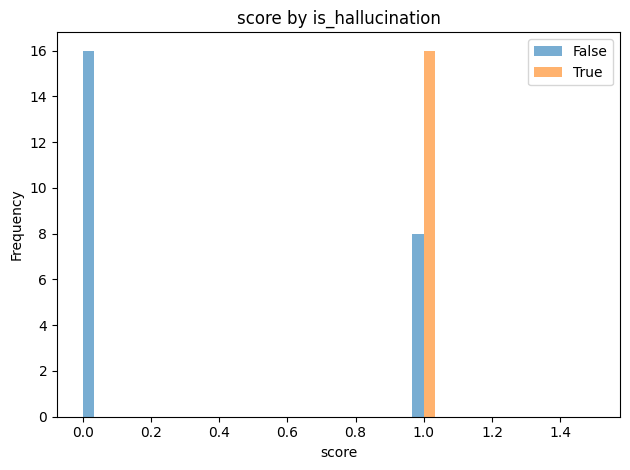

In [23]:
import matplotlib.pyplot as plt

def plot_split_histogram(df, value_col: str, bool_col: str, bins: int = 30, alpha: float = 0.6):
    fig, ax = plt.subplots()

    for group, data in df.groupby(bool_col)[value_col]:
        ax.hist(data, bins=bins, alpha=alpha, label=str(group))

    ax.set_xlabel(value_col)
    ax.set_ylabel("Frequency")
    ax.set_title(f"{value_col} by {bool_col}")
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_split_histogram(evaluations_df, value_col="score", bool_col="is_hallucination")

In [ ]:
evaluations_df["score_mean"] = evaluations_df.groupby(filter_columns)['score'].transform('mean')
evaluations_df["score_median"] = evaluations_df.groupby(filter_columns)['score'].transform('median')

#evaluation_df["score_std_incorrect"] = evaluation_df[~evaluation_df["is_correct"]].groupby(filter_columns)['score'].transform('std')
#evaluation_df["score_std_correct"] = evaluation_df[evaluation_df["is_correct"]].groupby(filter_columns)['score'].transform('std')

if normalise_threshold:
    #evaluation_df["threshold"] = evaluation_df["score_mean"]
    evaluations_df["threshold"] = evaluations_df["score_median"]
    evaluations_df["passed"] = np.where(evaluations_df["score"] > evaluations_df["threshold"], True, False)

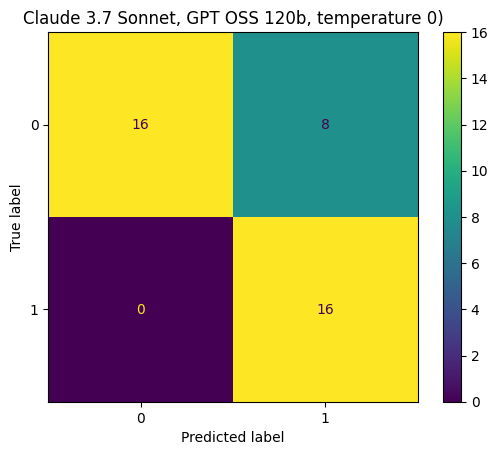

precision: 0.67, recall: 1.0, f1: 0.8

{'f1': 0.8,
 'model_name': 'Claude 3.7 Sonnet, GPT OSS 120b',
 'precision': 0.6666666666666666,
 'recall': 1.0,
 'score_diff': np.float64(0.6666666666666667),
 'score_hallucination': np.float64(1.0),
 'score_mean': np.float64(0.6),
 'score_median': np.float64(0.75),
 'score_not_hallucination': np.float64(0.3333333333333333),
 'temperature': '0'}


In [18]:
def get_results(df):
    results = {}

    results["model_name"] = f"{", ".join(df["model_name"].drop_duplicates().values)}"
    results["temperature"] = f"{str(df["temperature"].drop_duplicates().values[0])}"

    results["score_hallucination"] = df[df["is_hallucination"]]["score"].mean()
    results["score_not_hallucination"] = df[~df["is_hallucination"]]["score"].mean()
    results["score_diff"] = results["score_hallucination"] - results["score_not_hallucination"]
    results["score_mean"] = df["score_mean"].mean()
    results["score_median"] = df["score_median"].mean()
    #results["score_mean"] = (results["score_correct"] + results["score_incorrect"])/2
      
    results["precision"] = metrics.precision_score(df["is_hallucination"], df["passed"], zero_division=np.nan)
    results["recall"] = metrics.recall_score(df["is_hallucination"], df["passed"])
    results["f1"] = metrics.f1_score(df["is_hallucination"], df["passed"])
    confusion_matrix = metrics.confusion_matrix(df["is_hallucination"], df["passed"])
    
    cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
    cm_display.plot()
    #plt.title(f"{results["method"]} ({results["model_name"]})")
    plt.title(f"{results["model_name"]}, temperature {results["temperature"]})")
    plt.show()
    print(f"precision: {results["precision"]:.2}, recall: {results["recall"]:.2}, f1: {results["f1"]:.2}\n")
    
    return results

evaluations_df["score_mean"] = evaluations_df.groupby('model_name')['score'].transform('mean')
evaluations_df["score_median"] = evaluations_df.groupby('model_name')['score'].transform('median')

results = get_results(evaluations_df)
pprint.pprint(results)

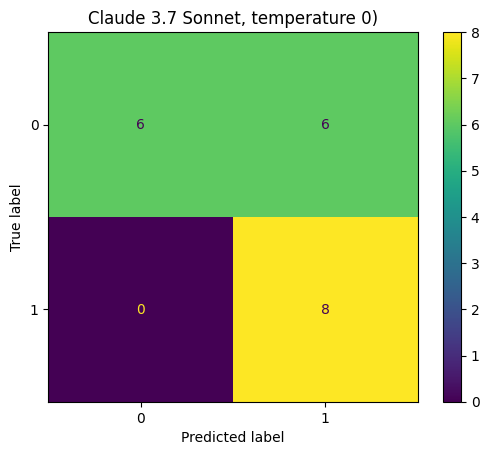

precision: 0.57, recall: 1.0, f1: 0.73



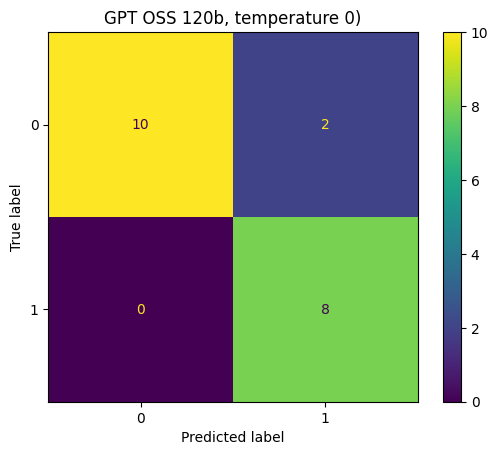

precision: 0.8, recall: 1.0, f1: 0.89



,model_name,temperature,score_hallucination,score_not_hallucination,score_diff,score_mean,score_median,precision,recall,f1
0,Claude 3.7 Sonnet,0,1.0,0.500000,0.500000,0.7,1.0,0.571429,1.0,0.727273
1,GPT OSS 120b,0,1.0,0.166667,0.833333,0.5,0.5,0.800000,1.0,0.888889


In [19]:
results_models = []
for row in evaluations_df[['model_name']].drop_duplicates().to_dict('records'):
    filter_df = evaluations_df.copy()
    filter_df = filter_df[filter_df['model_name'] == row['model_name']]

    if len(filter_df) > 0:
        results = get_results(filter_df)
        results_models.append(results)

results_df = pd.DataFrame(results_models)
results_df.to_csv('output/results.csv', index=False)
results_df

,temperature,score_hallucination,score_not_hallucination,score_diff,score_mean,score_median,precision,recall,f1
model_name,,,,,,,,,
Claude 3.7 Sonnet,0,1.0,0.500000,0.500000,0.7,1.0,0.571429,1.0,0.727273
GPT OSS 120b,0,1.0,0.166667,0.833333,0.5,0.5,0.800000,1.0,0.888889


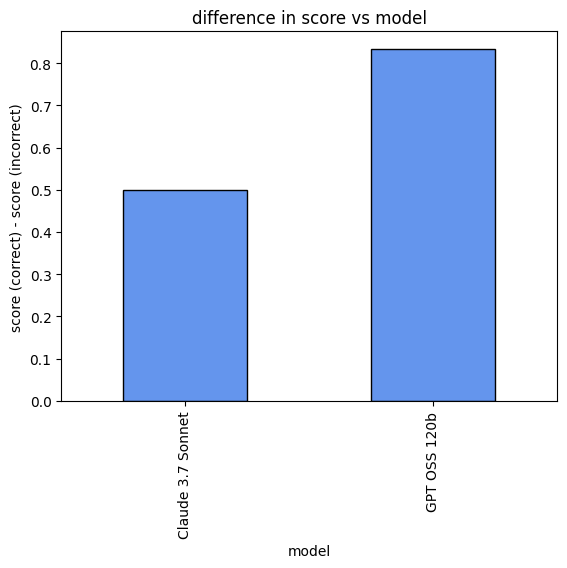

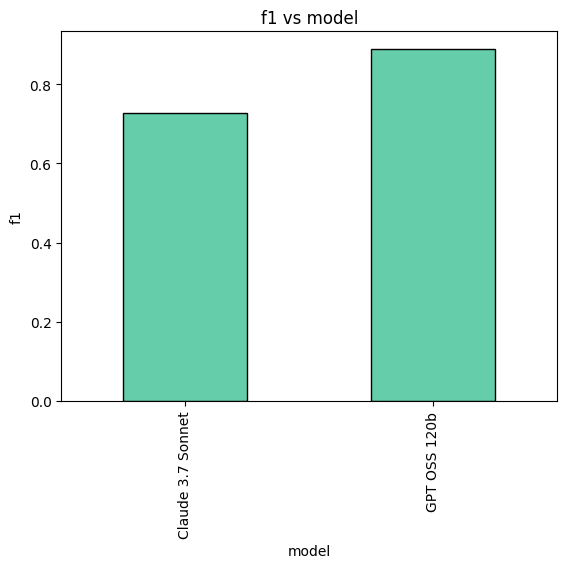

In [20]:
plot_df = results_df.set_index("model_name")

if len(plot_df) > 0:
    display(plot_df)
    plot_df["score_diff"].plot(kind="bar", xlabel="model",  ylabel="score (correct) - score (incorrect)", title=f"difference in score vs model", color="cornflowerblue", edgecolor="black")
    plt.show()
    plot_df["f1"].plot(kind="bar", xlabel="model", ylabel="f1", title=f"f1 vs model", color="mediumaquamarine", edgecolor="black")
    plt.show()